# Advanced Planning Evaluation - Run-Aware

This notebook evaluates all runs under `outputs/parsed`, preserves per-run metrics, and uses mean-across-runs aggregation for the main plots.

In [2]:
import os, re, math, warnings, itertools, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from typing import Dict, List, Set, Tuple, Optional, Any
from collections import defaultdict

try:
    from scipy.stats import spearmanr
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False
    warnings.warn("scipy not found — Spearman correlation will use pandas .corr()")

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, message='.*tight_layout.*')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("Imports OK  |  scipy:", HAS_SCIPY, " plotly:", HAS_PLOTLY)

Imports OK  |  scipy: True  plotly: True


In [3]:
# ============================================================
# CONFIGURATION - edit this cell only
# ============================================================

def _find_project_root(start: pathlib.Path = None) -> pathlib.Path:
    start = (start or pathlib.Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / "outputs").exists() and (cand / "tasks").exists():
            return cand
        for name in ("Benchmark_Framework", "Benchmark Framework"):
            nested = cand / name
            if (nested / "outputs").exists() and (nested / "tasks").exists():
                return nested
    raise FileNotFoundError("Could not locate Benchmark_Framework root.")


PROJECT_ROOT = _find_project_root()
RESULTS_DIR = PROJECT_ROOT / "outputs" / "parsed"
SCORED_DIR = PROJECT_ROOT / "outputs" / "scored"
TASKS_DIR = PROJECT_ROOT / "tasks"
PROTOCOLS_DIR = PROJECT_ROOT / "protocols"

MAX_FUZZY_DISTANCE = 2
COMPOSITE_WEIGHTS = {
    "fasr": 0.25,
    "iwsr": 0.20,
    "exec_ratio": 0.20,
    "one_minus_halluc": 0.20,
    "pas": 0.15,
}
COT_BONUS_WEIGHT = 0.05
BOOTSTRAP_N = 1000
DIFF_VALID = {"easy", "medium", "hard"}

# Leave as None to include every run under outputs/parsed.
SELECTED_RUN_IDS = None  # e.g. ["2026-05-26_15-54-44"]

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"RESULTS_DIR  : {RESULTS_DIR}  (exists={RESULTS_DIR.exists()})")
print(f"SCORED_DIR   : {SCORED_DIR}   (exists={SCORED_DIR.exists()})")
print(f"TASKS_DIR    : {TASKS_DIR}    (exists={TASKS_DIR.exists()})")


PROJECT_ROOT : C:\Users\SimoVane\Documents\GitHub\LLM_Benchmark\Benchmark_Framework
RESULTS_DIR  : C:\Users\SimoVane\Documents\GitHub\LLM_Benchmark\Benchmark_Framework\outputs\parsed  (exists=True)
SCORED_DIR   : C:\Users\SimoVane\Documents\GitHub\LLM_Benchmark\Benchmark_Framework\outputs\scored   (exists=True)
TASKS_DIR    : C:\Users\SimoVane\Documents\GitHub\LLM_Benchmark\Benchmark_Framework\tasks    (exists=True)


---
# Section 1 - Load Artifacts and PDDL Context

In [4]:
# ── General-purpose utilities ────────────────────────────────────────────────

def levenshtein(s1: str, s2: str) -> int:
    """Standard DP Levenshtein distance between two strings."""
    if s1 == s2:
        return 0
    if len(s1) < len(s2):
        s1, s2 = s2, s1
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1, 1):
        curr = [i]
        for j, c2 in enumerate(s2, 1):
            curr.append(min(prev[j] + 1, curr[j-1] + 1, prev[j-1] + (c1 != c2)))
        prev = curr
    return prev[-1]


_ACT_RE = re.compile(r'\(\s*([^\s()]+)((?:\s+[^\s()]+)*)\s*\)')

def parse_action(action_str: str) -> Tuple[Optional[str], List[str]]:
    """Parse '(action_name arg1 arg2 ...)' into (name, [args])."""
    m = _ACT_RE.match(action_str.strip())
    if not m:
        return None, []
    name = m.group(1).lower()
    args = m.group(2).strip().lower().split() if m.group(2).strip() else []
    return name, args


def extract_pddl_actions_from_text(text: str) -> List[str]:
    """Return all PDDL-style action strings from arbitrary text."""
    return re.findall(r'\([^()\n]+\)', text)

print("Helpers defined.")

Helpers defined.


In [ ]:
# ── PDDL Domain Parser ───────────────────────────────────────────────────────

def parse_domain_pddl(domain_path: str) -> Dict:
    """
    Parse a PDDL domain file.

    Input : path to domain.pddl
    Output: dict with keys
        action_names  - set of lowercase action schema names
        predicates    - set of lowercase predicate names
        functions     - set of lowercase function/fluent names
        schemas       - dict  action_name -> {params, prec_raw, eff_raw}

    Detects: which tokens an LLM plan can legally use.
    """
    result = dict(action_names=set(), predicates=set(), functions=set(), schemas={})
    try:
        text = open(domain_path, encoding='utf-8', errors='replace').read()
        text = re.sub(r';[^\n]*', '', text).lower()

        # predicates
        pm = re.search(r'\(:predicates(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if pm:
            result['predicates'] = set(re.findall(r'\(\s*([a-z][a-z0-9_-]*)', pm.group(1)))

        # functions / fluents
        fm = re.search(r'\(:functions(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if fm:
            result['functions'] = set(re.findall(r'\(\s*([a-z][a-z0-9_-]*)', fm.group(1)))

        # action schemas
        for m in re.finditer(r'\(:action\s+([a-z][a-z0-9_-]*)', text):
            aname  = m.group(1)
            start  = m.start()
            # find end of this action block
            nxt = re.search(r'\(:action|\(:durative|\Z', text[start + 1:])
            block  = text[start: start + 1 + (nxt.start() if nxt else len(text))]

            result['action_names'].add(aname)

            params_m = re.search(r':parameters\s*\(([^)]*)\)', block)
            params   = re.findall(r'\?([a-z][a-z0-9_-]*)', params_m.group(1)) if params_m else []

            prec_pos = block.find(':precondition')
            eff_pos  = block.find(':effect')
            prec_raw = block[prec_pos + len(':precondition'):eff_pos].strip() if prec_pos != -1 and eff_pos != -1 else ''
            eff_raw  = block[eff_pos  + len(':effect'):].strip()              if eff_pos  != -1                    else ''

            result['schemas'][aname] = dict(params=params, prec_raw=prec_raw, eff_raw=eff_raw)

    except Exception as e:
        warnings.warn(f"[domain parser] {domain_path}: {e}")
    return result


def parse_problem_pddl(problem_path: str) -> Dict:
    """
    Parse a PDDL problem file.

    Input : path to instance .pddl
    Output: dict with keys
        objects      - set of lowercase object identifiers
        init_atoms   - set of tuples (predicate, *args) for propositional facts
        init_numeric - dict (function, *args) -> float for numeric inits

    Detects: which objects and facts exist in the initial state.
    """
    result = dict(objects=set(), init_atoms=set(), init_numeric={})
    try:
        text = open(problem_path, encoding='utf-8', errors='replace').read()
        text = re.sub(r';[^\n]*', '', text).lower()

        # objects
        om = re.search(r'\(:objects(.*?)\)(?=\s*\(:|\s*\))', text, re.DOTALL)
        if om:
            for tok in om.group(1).split():
                if not tok.startswith('-') and re.match(r'^[a-z][a-z0-9_-]*$', tok):
                    result['objects'].add(tok)

        # init
        im = re.search(r'\(:init(.*?)(?=\(:goal|\(:metric|\Z)', text, re.DOTALL)
        if im:
            init_txt = im.group(1)
            # numeric: (= (func args...) value)
            for nm in re.finditer(r'\(=\s*\(\s*([a-z][a-z0-9_-]*)([^)]*)\)\s*([\d.]+)\s*\)', init_txt):
                key = (nm.group(1),) + tuple(nm.group(2).strip().split())
                result['init_numeric'][key] = float(nm.group(3))
            # propositional: (pred arg...)
            for am in re.finditer(r'\(([a-z][a-z0-9_-]*(?:\s+[a-z0-9][a-z0-9_-]*)*)\)', init_txt):
                tokens = am.group(1).split()
                if tokens[0] not in {'=', 'not', 'and', 'or', 'increase', 'decrease'}:
                    result['init_atoms'].add(tuple(tokens))

    except Exception as e:
        warnings.warn(f"[problem parser] {problem_path}: {e}")
    return result

print("PDDL parsers defined.")

PDDL parsers defined.


In [6]:
# ── Index PDDL domain/problem files ──────────────────────────────────────────
# Builds domain_info[domain_name] and problem_info[(domain, difficulty, instance)]

domain_info: Dict[str, Dict]  = {}
problem_info: Dict[Tuple, Dict] = {}
pddl_difficulty_map: Dict[str, str] = {}   # (domain, instance_stem) -> difficulty

_DIFF_FOLDERS = {'easy', 'medium', 'hard'}

if TASKS_DIR.exists():
    for domain_dir in sorted(TASKS_DIR.iterdir()):
        if not domain_dir.is_dir() or domain_dir.name.startswith('_') or domain_dir.name == 'metadata':
            continue
        dname = domain_dir.name

        # domain.pddl
        dp = domain_dir / 'domain' / 'domain.pddl'
        if dp.exists():
            domain_info[dname] = parse_domain_pddl(str(dp))
            domain_info[dname]['path'] = str(dp)
        else:
            domain_info[dname] = dict(action_names=set(), predicates=set(),
                                      functions=set(), schemas={}, path=None)

        # problem instances per difficulty
        for diff in _DIFF_FOLDERS:
            diff_dir = domain_dir / diff
            if not diff_dir.exists():
                continue
            for pf in sorted(diff_dir.glob('*.pddl')):
                key = (dname, diff, pf.stem)
                problem_info[key] = parse_problem_pddl(str(pf))
                problem_info[key]['path']       = str(pf)
                problem_info[key]['difficulty'] = diff
                pddl_difficulty_map[(dname, pf.stem)] = diff

print(f"Domains indexed : {sorted(domain_info.keys())}")
print(f"Problem files   : {len(problem_info)}")

Domains indexed : ['block-grouping', 'expedition', 'fo-counters', 'fo-sailing', 'rover', 'settlersnumeric']
Problem files   : 120


In [7]:
# -- Load parsed/scored artifacts into df_raw ---------------------------------
# Expected layout:
#   outputs/parsed/<run_id>/<model_id>/<protocol_id>/<domain>/<difficulty>/<instance>.json
#   outputs/scored/<run_id>/<model_id>/<protocol_id>/<domain>/<difficulty>/<instance>.json

import json as _json

_PROTOCOL_COT: Dict[str, bool] = {}
if PROTOCOLS_DIR.exists():
    for protocol_file in sorted(PROTOCOLS_DIR.glob("*.yaml")):
        try:
            text = protocol_file.read_text(encoding="utf-8")
            pid_m = re.search(r"^protocol_id\s*:\s*(\S+)", text, re.MULTILINE)
            cot_m = re.search(r"include_chain_of_thought\s*:\s*(\S+)", text)
            if pid_m and cot_m:
                _PROTOCOL_COT[pid_m.group(1)] = cot_m.group(1).lower() == "true"
        except Exception as exc:
            warnings.warn(f"[protocol loader] {protocol_file.name}: {exc}")
print("Protocol CoT flags:", _PROTOCOL_COT)


def _read_scored(run_id: str, model: str, protocol: str, domain: str, difficulty: str, instance: str) -> Optional[Dict]:
    p = SCORED_DIR / run_id / model / protocol / domain / difficulty / f"{instance}.json"
    if not p.exists():
        return None
    try:
        return _json.loads(p.read_text(encoding="utf-8"))
    except Exception as exc:
        warnings.warn(f"[scored read] {p}: {exc}")
        return None


rows = []
selected = set(SELECTED_RUN_IDS) if SELECTED_RUN_IDS else None

if RESULTS_DIR.exists():
    for run_dir in sorted(RESULTS_DIR.iterdir()):
        if not run_dir.is_dir() or run_dir.name.startswith("."):
            continue
        run_id = run_dir.name
        if selected and run_id not in selected:
            continue

        for model_dir in sorted(run_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            model = model_dir.name
            for protocol_dir in sorted(model_dir.iterdir()):
                if not protocol_dir.is_dir():
                    continue
                protocol = protocol_dir.name
                cot_protocol = _PROTOCOL_COT.get(protocol, False)
                for domain_dir in sorted(protocol_dir.iterdir()):
                    if not domain_dir.is_dir():
                        continue
                    domain = domain_dir.name
                    for diff_dir in sorted(domain_dir.iterdir()):
                        if not diff_dir.is_dir() or diff_dir.name not in DIFF_VALID:
                            continue
                        difficulty = diff_dir.name
                        for json_file in sorted(diff_dir.glob("*.json")):
                            instance = json_file.stem
                            try:
                                parsed_data = _json.loads(json_file.read_text(encoding="utf-8"))
                            except Exception as exc:
                                warnings.warn(f"[load] {json_file}: {exc}")
                                continue

                            attempts = parsed_data.get("attempts", [])
                            actions, cot_text = [], ""
                            for attempt in reversed(attempts):
                                pp = attempt.get("parsed_plan") or {}
                                candidate = pp.get("actions") or []
                                if candidate:
                                    actions = candidate
                                    cot_text = pp.get("reasoning", "")
                                    break
                            if not actions and attempts:
                                pp = attempts[-1].get("parsed_plan") or {}
                                actions = pp.get("actions") or []
                                cot_text = pp.get("reasoning", "")

                            scored = _read_scored(run_id, model, protocol, domain, difficulty, instance)
                            if scored is not None:
                                is_valid = bool(scored.get("solved", False))
                                n_iters = scored.get("iterations_used", len(attempts))
                            else:
                                warnings.warn(
                                    f"[load] no scored file for {run_id}/{model}/{protocol}/"
                                    f"{domain}/{difficulty}/{instance}"
                                )
                                is_valid = False
                                n_iters = len(attempts)

                            rows.append(dict(
                                Model=model,
                                Domain=domain,
                                Problem=instance,
                                Difficulty=difficulty,
                                Protocol=protocol,
                                Run_id=run_id,
                                Valid=is_valid,
                                Length=len(actions),
                                Iterations=n_iters,
                                Chain_of_Thought=cot_protocol or bool(cot_text.strip()),
                                _actions=actions,
                                _cot_text=cot_text,
                                _file_path=str(json_file),
                            ))
else:
    warnings.warn(f"RESULTS_DIR does not exist: {RESULTS_DIR}.")

df_raw = pd.DataFrame(rows)
raw_columns = [
    "Model", "Domain", "Problem", "Difficulty", "Protocol", "Run_id",
    "Valid", "Length", "Iterations", "Chain_of_Thought",
    "_actions", "_cot_text", "_file_path",
]
if df_raw.empty:
    print("No data found. Metric and plot cells will skip safely.")
    df_raw = pd.DataFrame(columns=raw_columns)
else:
    df_raw["Iterations"] = pd.to_numeric(df_raw["Iterations"], errors="coerce")
    print(f"Loaded {len(df_raw)} plan records")
    print(f"  Runs      : {sorted(df_raw['Run_id'].unique())}")
    print(f"  Models    : {sorted(df_raw['Model'].unique())}")
    print(f"  Domains   : {sorted(df_raw['Domain'].unique())}")
    print(f"  Protocols : {sorted(df_raw['Protocol'].unique())}")

df_raw.head()


Protocol CoT flags: {'direct_plan': False, 'direct_plan_with_rationale': True, 'iterative_repair': True}
Loaded 6 plan records
  Runs      : ['2026-05-29_17-03-19']
  Models    : ['nvidia_gemma_4_31b_it', 'nvidia_gpt_oss_120b', 'nvidia_llama_3_3_70b_instruct', 'nvidia_nemotron_3_nano_30b_a3b', 'nvidia_phi_4_mini_instruct', 'nvidia_qwen_3_5_122b_a10b']
  Domains   : ['fo-sailing']
  Protocols : ['iterative_repair']


,Model,Domain,Problem,Difficulty,Protocol,Run_id,Valid,Length,Iterations,Chain_of_Thought,_actions,_cot_text,_file_path
0,nvidia_gemma_4_31b_it,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,1,True,[],,C:\Users\SimoVane\Documents\GitHub\LLM_Benchma...
1,nvidia_gpt_oss_120b,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,171,5,True,"[(accelerate b0), (accelerate b0), (go_south b...",,C:\Users\SimoVane\Documents\GitHub\LLM_Benchma...
2,nvidia_llama_3_3_70b_instruct,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,4,5,True,"[(decelerate b0), (go_south_east b0), (deceler...",,C:\Users\SimoVane\Documents\GitHub\LLM_Benchma...
3,nvidia_nemotron_3_nano_30b_a3b,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,5,True,[],,C:\Users\SimoVane\Documents\GitHub\LLM_Benchma...
4,nvidia_phi_4_mini_instruct,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,1,True,[],,C:\Users\SimoVane\Documents\GitHub\LLM_Benchma...


In [8]:
# -- Consistent color palette per model ---------------------------------------
ALL_MODELS = sorted(df_raw["Model"].unique()) if not df_raw.empty else []
_base_colors = sns.color_palette("tab20", max(1, len(ALL_MODELS)))
MODEL_PALETTE = {model: _base_colors[i % len(_base_colors)] for i, model in enumerate(ALL_MODELS)}
print("Palette prepared for", len(MODEL_PALETTE), "models")


Palette prepared for 6 models


---
# Section 2 - Row-Level Metrics

In [ ]:
def compute_hallucination_metrics(actions: List[str],
                                  d_info: Dict,
                                  p_info: Dict) -> Dict:
    """
    Compute action and object hallucination rates for a single plan.

    Input:
        actions - list of raw action strings from the plan
        d_info  - domain info dict (from parse_domain_pddl)
        p_info  - problem info dict (from parse_problem_pddl)

    Output: dict with
        hallucinated_action_count, fuzzy_hallucinated_count,
        object_hallucination_count, total_action_count, total_arg_count,
        hallucination_rate, fuzzy_hallucination_rate, object_hallucination_rate

    Detects: invented action names and invented object references.
    """
    legal_actions = d_info.get('action_names', set())
    legal_objects = p_info.get('objects', set())

    hall_strict = hall_fuzzy = obj_hall = total_acts = total_args = 0

    for act_str in actions:
        aname, aargs = parse_action(act_str)
        if aname is None:
            continue
        total_acts += 1
        total_args += len(aargs)

        if aname not in legal_actions:
            hall_strict += 1
            # check fuzzy (nearest legal action within threshold)
            if not legal_actions or min(levenshtein(aname, la) for la in legal_actions) > MAX_FUZZY_DISTANCE:
                hall_fuzzy += 1

        for arg in aargs:
            if legal_objects and arg not in legal_objects:
                obj_hall += 1

    return dict(
        hallucinated_action_count   = hall_strict,
        fuzzy_hallucinated_count    = hall_fuzzy,
        object_hallucination_count  = obj_hall,
        total_action_count          = total_acts,
        total_arg_count             = total_args,
        hallucination_rate          = hall_strict / total_acts if total_acts else float('nan'),
        fuzzy_hallucination_rate    = hall_fuzzy  / total_acts if total_acts else float('nan'),
        object_hallucination_rate   = obj_hall    / total_args if total_args else float('nan'),
    )

print("compute_hallucination_metrics() defined.")

compute_hallucination_metrics() defined.


In [10]:
class PDDLSimulator:
    """
    Lightweight propositional + numeric PDDL simulator.

    Supports STRIPS-style propositional state and simple numeric fluents
    (increase/decrease with constant or single-fluent amounts).
    Complex numeric expressions (nested arithmetic in preconditions) are
    evaluated on a best-effort basis; failures are treated as state fabrications.
    """

    def __init__(self, d_info: Dict, p_info: Dict):
        self.d_info    = d_info
        self.prop      = set(p_info.get('init_atoms', set()))          # set of tuples
        self.num       = dict(p_info.get('init_numeric', {}))          # key-tuple -> float
        self.prop_hist = [frozenset(self.prop)]                        # history for temporal dist
        self.step      = 0

    # ── grounding ────────────────────────────────────────────────────────────
    def _ground(self, raw: str, params: List[str], args: List[str]) -> str:
        result = raw
        for p, a in zip(params, args):
            result = re.sub(r'\?' + re.escape(p) + r'\b', a, result)
        return result

    # ── numeric expression evaluator (best-effort) ────────────────────────────
    def _eval_num(self, expr: str) -> Optional[float]:
        expr = expr.strip()
        try:
            return float(expr)
        except ValueError:
            pass
        # (func arg ...)
        m = re.match(r'^\(\s*([a-z][a-z0-9_-]*)([^)]*)\)$', expr)
        if m:
            key = (m.group(1),) + tuple(m.group(2).strip().split())
            return self.num.get(key)
        # (op e1 e2) — find split at depth 0
        m2 = re.match(r'^\(\s*([+\-*/])\s(.+)\)$', expr, re.DOTALL)
        if m2:
            op, inner = m2.group(1), m2.group(2).strip()
            depth, pos = 0, 0
            operands = []
            start = 0
            for i, ch in enumerate(inner):
                if ch == '(':
                    depth += 1
                elif ch == ')':
                    depth -= 1
                elif ch == ' ' and depth == 0:
                    seg = inner[start:i].strip()
                    if seg:
                        operands.append(seg)
                    start = i + 1
            seg = inner[start:].strip()
            if seg:
                operands.append(seg)
            if len(operands) == 2:
                v1, v2 = self._eval_num(operands[0]), self._eval_num(operands[1])
                if v1 is not None and v2 is not None:
                    return {'+': v1+v2, '-': v1-v2, '*': v1*v2,
                             '/': v1/v2 if v2 else None}.get(op)
        return None

    # ── precondition checking ─────────────────────────────────────────────────
    def check_preconditions(self, prec_raw: str, params: List[str], args: List[str]):
        """
        Returns (satisfied: bool, failed_prop: list, failed_num: list).
        failed_prop holds tuple atoms that are missing from current state.
        failed_num  holds raw numeric condition strings that are violated.
        """
        grounded = self._ground(prec_raw, params, args)
        failed_prop, failed_num = [], []
        funcs = self.d_info.get('functions', set())
        skip_heads = {'and','or','not','>=','<=','>','<','=',
                      'increase','decrease','when','forall','exists',
                      '+','-','*','/'}

        # numeric comparisons
        for nm in re.finditer(r'\((>=|<=|>|<)\s*([^)]+)\s*([0-9.]+)\s*\)', grounded):
            op_s, lhs_s, rhs_s = nm.group(1), nm.group(2).strip(), nm.group(3)
            lhs = self._eval_num(lhs_s)
            rhs = float(rhs_s)
            if lhs is None:
                continue
            ok = {'>=': lhs>=rhs, '<=': lhs<=rhs, '>': lhs>rhs, '<': lhs<rhs}[op_s]
            if not ok:
                failed_num.append(nm.group(0))

        # propositional atoms
        no_neg = re.sub(r'\(not\s+\([^)]+\)\s*\)', '', grounded)
        for am in re.finditer(r'\(([a-z][a-z0-9_-]*)([^()]*)\)', no_neg):
            head = am.group(1)
            if head in skip_heads or head in funcs:
                continue
            atom = (head,) + tuple(am.group(2).strip().split()) if am.group(2).strip() else (head,)
            if atom not in self.prop:
                failed_prop.append(atom)

        sat = not failed_prop and not failed_num
        return sat, failed_prop, failed_num

    # ── effect application ────────────────────────────────────────────────────
    def apply_effects(self, eff_raw: str, params: List[str], args: List[str]):
        grounded = self._ground(eff_raw, params, args)
        funcs    = self.d_info.get('functions', set())
        skip_h   = {'and','or','not','>=','<=','>','<','=',
                    'increase','decrease','when','forall','assign','+','-','*','/'}

        # delete effects: (not (pred args))
        for dm in re.finditer(r'\(not\s+\(([a-z][a-z0-9_-]*)([^)]*)\)\s*\)', grounded):
            atom = (dm.group(1),) + tuple(dm.group(2).strip().split())
            self.prop.discard(atom)

        # add effects (ignore numeric ops)
        no_del = re.sub(r'\(not\s+\([^)]+\)\s*\)', '', grounded)
        for am in re.finditer(r'\(([a-z][a-z0-9_-]*)([^()]*)\)', no_del):
            head = am.group(1)
            if head in skip_h or head in funcs:
                continue
            atom = (head,) + tuple(am.group(2).strip().split()) if am.group(2).strip() else (head,)
            self.prop.add(atom)

        # numeric effects: (increase (func args) val) / (decrease ...)
        for op_name in ('increase', 'decrease'):
            for nm in re.finditer(
                    r'\(' + op_name + r'\s+\(\s*([a-z][a-z0-9_-]*)([^)]*)\)\s*([0-9.]+|\([^)]+\))\s*\)',
                    grounded):
                key = (nm.group(1),) + tuple(nm.group(2).strip().split())
                val = self._eval_num(nm.group(3).strip())
                if val is not None:
                    if op_name == 'increase':
                        self.num[key] = self.num.get(key, 0.0) + val
                    else:
                        self.num[key] = self.num.get(key, 0.0) - val

        self.prop_hist.append(frozenset(self.prop))
        self.step += 1

    # ── temporal history queries ──────────────────────────────────────────────
    def last_step_atom_true(self, atom) -> int:
        """Return the most recent step where atom held, or -1 if never."""
        for i in range(len(self.prop_hist) - 1, -1, -1):
            if atom in self.prop_hist[i]:
                return i
        return -1

print("PDDLSimulator defined.")

PDDLSimulator defined.


In [ ]:
def compute_precondition_metrics(actions: List[str], d_info: Dict, p_info: Dict,
                                  label: str = '') -> Dict:
    """
    Simulate plan execution and compute precondition-awareness metrics.

    Input:
        actions - list of raw action strings
        d_info  - domain info dict
        p_info  - problem info dict
        label   - used only for warning messages

    Output: dict with
        executability_prefix_length, executability_ratio,
        sequencing_error_count, state_fabrication_count,
        precondition_awareness_score, mean_temporal_distance

    Classifies failures:
        sequencing_error   - precondition predicate was true at some earlier step
        state_fabrication  - predicate was never established in any prefix state
    """
    nan_result = dict(
        executability_prefix_length = 0,
        executability_ratio         = float('nan'),
        sequencing_error_count      = 0,
        state_fabrication_count     = 0,
        precondition_awareness_score= float('nan'),
        mean_temporal_distance      = float('nan'),
    )
    n = len(actions)
    if n == 0:
        return nan_result

    try:
        sim = PDDLSimulator(d_info, p_info)
        schemas = d_info.get('schemas', {})

        first_failure = n
        seq_errs, fab_errs = 0, 0
        temporal_dists: List[float] = []

        for step, act_str in enumerate(actions):
            aname, aargs = parse_action(act_str)
            if aname is None:
                continue
            schema = schemas.get(aname)
            if schema is None:
                continue  # unknown action — skip without failing

            params   = schema.get('params', [])
            prec_raw = schema.get('prec_raw', '')
            eff_raw  = schema.get('eff_raw', '')

            if len(params) != len(aargs):
                if first_failure == n:
                    first_failure = step
                fab_errs += 1
                break

            sat, failed_prop, failed_num = sim.check_preconditions(prec_raw, params, aargs)

            if not sat:
                if first_failure == n:
                    first_failure = step
                for atom in failed_prop:
                    last = sim.last_step_atom_true(atom)
                    if last >= 0:
                        seq_errs += 1
                        temporal_dists.append(step - last)
                    else:
                        fab_errs += 1
                fab_errs += len(failed_num)  # numeric failures → fabrication
                break

            sim.apply_effects(eff_raw, params, aargs)

        total_fail = seq_errs + fab_errs
        return dict(
            executability_prefix_length  = first_failure,
            executability_ratio          = first_failure / n,
            sequencing_error_count       = seq_errs,
            state_fabrication_count      = fab_errs,
            precondition_awareness_score = seq_errs / total_fail if total_fail > 0 else float('nan'),
            mean_temporal_distance       = float(np.mean(temporal_dists)) if temporal_dists else float('nan'),
        )
    except Exception as e:
        warnings.warn(f"[simulator] {label}: {e}")
        return nan_result

print("compute_precondition_metrics() defined.")

compute_precondition_metrics() defined.


In [ ]:
def compute_cot_alignment(cot_text: str, actions: List[str],
                           d_info: Dict, p_info: Dict) -> Dict:
    """
    Compute CoT-plan alignment score for one plan.

    Input:
        cot_text - chain-of-thought reasoning text extracted from plan file
        actions  - list of raw action strings in the final plan
        d_info   - domain info dict
        p_info   - problem info dict

    Output: dict with
        cot_action_coverage, cot_object_coverage, cot_alignment_score

    Detects: whether the model's reasoning references the actions and objects
    it later uses, indicating genuine planning vs post-hoc generation.
    """
    legal_action_names = d_info.get('action_names', set())
    legal_objects      = p_info.get('objects', set())
    cot_lower          = cot_text.lower()
    cot_tokens         = set(re.findall(r'[a-z][a-z0-9_-]*', cot_lower))

    # plan action names and arguments
    plan_anames, plan_objs = set(), set()
    for act in actions:
        n, args = parse_action(act)
        if n:
            plan_anames.add(n)
            plan_objs.update(args)

    cot_act_mentioned = cot_tokens & legal_action_names
    cot_obj_mentioned = cot_tokens & legal_objects

    cot_action_cov = len(cot_act_mentioned & plan_anames) / max(len(plan_anames), 1)
    cot_object_cov = len(cot_obj_mentioned & plan_objs)  / max(len(plan_objs),   1)
    cot_align      = (cot_action_cov + cot_object_cov) / 2

    return dict(
        cot_action_coverage  = cot_action_cov,
        cot_object_coverage  = cot_object_cov,
        cot_alignment_score  = cot_align,
    )

print("compute_cot_alignment() defined.")

compute_cot_alignment() defined.


In [ ]:
def compute_composite_score(model_stats: Dict, weights: Dict,
                             cot_bonus_w: float = 0.05) -> float:
    """
    Compute the Composite Planning Score for one model.

    Input:
        model_stats   - dict with keys: fasr, iwsr, exec_ratio,
                          one_minus_halluc, pas, cot_alignment (optional, may be nan)
        weights       - COMPOSITE_WEIGHTS dict (must sum to 1.0)
        cot_bonus_w   - extra weight for CoT alignment; only applied if not nan

    Output: float PS in [0, 1]

    Detects: overall planning quality accounting for all dimensions.
    """
    base = (
        weights['fasr']             * model_stats.get('fasr', 0) +
        weights['iwsr']             * model_stats.get('iwsr', 0) +
        weights['exec_ratio']       * model_stats.get('exec_ratio', 0) +
        weights['one_minus_halluc'] * model_stats.get('one_minus_halluc', 0) +
        weights['pas']              * model_stats.get('pas', 0.5)
    )
    cot = model_stats.get('cot_alignment', float('nan'))
    if not math.isnan(cot):
        # renormalise so total = 1.0
        total_w = sum(weights.values()) + cot_bonus_w
        base = (base + cot_bonus_w * cot) / total_w
    return float(np.clip(base, 0, 1))

print("compute_composite_score() defined.")

compute_composite_score() defined.


In [14]:
# -- Compute row-level metrics into df_metrics --------------------------------
df_metrics = df_raw.copy()

halluc_cols = [
    "hallucinated_action_count", "fuzzy_hallucinated_count",
    "object_hallucination_count", "total_action_count", "total_arg_count",
    "hallucination_rate", "fuzzy_hallucination_rate", "object_hallucination_rate",
    "pddl_available",
]
prec_cols = [
    "executability_prefix_length", "executability_ratio",
    "sequencing_error_count", "state_fabrication_count",
    "precondition_awareness_score", "mean_temporal_distance",
]
cot_cols = ["cot_action_vocab_overlap", "cot_object_vocab_overlap", "cot_alignment_score"]

if df_metrics.empty:
    for col in halluc_cols + prec_cols + cot_cols + ["_iter1", "_iwsr_contrib"]:
        df_metrics[col] = pd.Series(dtype="float64")
else:
    halluc_rows, prec_rows, cot_rows = [], [], []
    for _, row in df_metrics.iterrows():
        dom = row["Domain"]
        inst = row["Problem"]
        diff = row.get("Difficulty", "unknown")
        dinfo = domain_info.get(dom, {})
        pinfo = problem_info.get((dom, diff, inst), {})
        pddl_ok = bool(dinfo.get("action_names")) and bool(pinfo.get("objects"))

        try:
            hm = compute_hallucination_metrics(row["_actions"], dinfo, pinfo)
        except Exception as exc:
            warnings.warn(f"Hallucination error {row['_file_path']}: {exc}")
            hm = {k: float("nan") for k in halluc_cols if k != "pddl_available"}
        hm["pddl_available"] = pddl_ok
        halluc_rows.append(hm)

        prec_rows.append(compute_precondition_metrics(row["_actions"], dinfo, pinfo, label=row["_file_path"]))

        try:
            cot_rows.append(compute_cot_alignment(row.get("_cot_text", ""), row["_actions"], dinfo, pinfo))
        except Exception as exc:
            warnings.warn(f"CoT alignment error {row['_file_path']}: {exc}")
            cot_rows.append({k: float("nan") for k in cot_cols})

    df_metrics = pd.concat([
        df_metrics.reset_index(drop=True),
        pd.DataFrame(halluc_rows).reset_index(drop=True),
        pd.DataFrame(prec_rows).reset_index(drop=True),
        pd.DataFrame(cot_rows).reset_index(drop=True),
    ], axis=1)
    df_metrics["_iter1"] = (df_metrics["Valid"] == True) & (df_metrics["Iterations"] == 1)
    df_metrics["_iwsr_contrib"] = df_metrics.apply(
        lambda r: (1.0 / r["Iterations"]) if bool(r["Valid"]) and pd.notna(r["Iterations"]) and r["Iterations"] > 0 else 0.0,
        axis=1,
    )

print("df_raw shape    :", df_raw.shape)
print("df_metrics shape:", df_metrics.shape)
df_metrics.head()


df_raw shape    : (6, 13)
df_metrics shape: (6, 33)


,Model,Domain,Problem,Difficulty,Protocol,Run_id,Valid,Length,Iterations,Chain_of_Thought,...,executability_ratio,sequencing_error_count,state_fabrication_count,precondition_awareness_score,mean_temporal_distance,cot_action_coverage,cot_object_coverage,cot_alignment_score,_iter1,_iwsr_contrib
0,nvidia_gemma_4_31b_it,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,1,True,...,NaN,0,0,NaN,NaN,0.0,0.0,0.0,False,0.0
1,nvidia_gpt_oss_120b,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,171,5,True,...,0.011696,0,1,0.0,NaN,0.0,0.0,0.0,False,0.0
2,nvidia_llama_3_3_70b_instruct,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,4,5,True,...,0.250000,0,1,0.0,NaN,0.0,0.0,0.0,False,0.0
3,nvidia_nemotron_3_nano_30b_a3b,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,5,True,...,NaN,0,0,NaN,NaN,0.0,0.0,0.0,False,0.0
4,nvidia_phi_4_mini_instruct,fo-sailing,pfile1,easy,iterative_repair,2026-05-29_17-03-19,False,0,1,True,...,NaN,0,0,NaN,NaN,0.0,0.0,0.0,False,0.0


---
# Section 3 - Run-Aware Tables

In [15]:
# -- Run-aware aggregation tables ---------------------------------------------
def _nanmean_or_default(series: pd.Series, default: float = np.nan) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna()
    return float(values.mean()) if len(values) else default


def _compute_ps_from_row(row: pd.Series) -> float:
    return compute_composite_score(dict(
        fasr=float(row.get("FASR", 0) or 0),
        iwsr=float(row.get("IWSR", 0) or 0),
        exec_ratio=float(row.get("Exec", 0) or 0) if pd.notna(row.get("Exec", np.nan)) else 0,
        one_minus_halluc=1 - float(row.get("Halluc", 0) or 0) if pd.notna(row.get("Halluc", np.nan)) else 0.5,
        pas=float(row.get("PAS", 0.5) or 0.5) if pd.notna(row.get("PAS", np.nan)) else 0.5,
        cot_alignment=float(row.get("CoT_Alignment", np.nan)) if pd.notna(row.get("CoT_Alignment", np.nan)) else float("nan"),
    ), COMPOSITE_WEIGHTS, COT_BONUS_WEIGHT)


if df_metrics.empty:
    run_table = pd.DataFrame()
    agg_table = pd.DataFrame()
    model_run_table = pd.DataFrame()
    model_overall = pd.DataFrame()
else:
    run_table = df_metrics.groupby(["Run_id", "Model", "Domain", "Protocol"], dropna=False).agg(
        N=("Problem", "count"),
        Problems=("Problem", "nunique"),
        Success_Rate=("Valid", "mean"),
        FASR=("_iter1", "mean"),
        IWSR=("_iwsr_contrib", "mean"),
        Exec=("executability_ratio", "mean"),
        Halluc=("hallucination_rate", "mean"),
        Fuzzy_Halluc=("fuzzy_hallucination_rate", "mean"),
        Object_Halluc=("object_hallucination_rate", "mean"),
        PAS=("precondition_awareness_score", lambda x: _nanmean_or_default(x, 0.5)),
        CoT_Alignment=("cot_alignment_score", lambda x: _nanmean_or_default(x, np.nan)),
        Seq_Errors=("sequencing_error_count", "sum"),
        Fab_Errors=("state_fabrication_count", "sum"),
        Avg_Length=("Length", "mean"),
        Avg_Iterations=("Iterations", "mean"),
    ).reset_index()
    run_table["PS"] = run_table.apply(_compute_ps_from_row, axis=1)

    agg_table = run_table.groupby(["Model", "Domain"], dropna=False).agg(
        Runs=("Run_id", "nunique"),
        Protocols=("Protocol", "nunique"),
        N=("N", "sum"),
        Success_Rate=("Success_Rate", "mean"),
        Success_Rate_std=("Success_Rate", "std"),
        FASR=("FASR", "mean"),
        FASR_std=("FASR", "std"),
        IWSR=("IWSR", "mean"),
        IWSR_std=("IWSR", "std"),
        Exec=("Exec", "mean"),
        Exec_std=("Exec", "std"),
        Halluc=("Halluc", "mean"),
        Halluc_std=("Halluc", "std"),
        Fuzzy_Halluc=("Fuzzy_Halluc", "mean"),
        Object_Halluc=("Object_Halluc", "mean"),
        PAS=("PAS", "mean"),
        PAS_std=("PAS", "std"),
        CoT_Alignment=("CoT_Alignment", "mean"),
        PS=("PS", "mean"),
        PS_std=("PS", "std"),
    ).reset_index().fillna({
        "Success_Rate_std": 0, "FASR_std": 0, "IWSR_std": 0,
        "Exec_std": 0, "Halluc_std": 0, "PAS_std": 0, "PS_std": 0,
    })

    model_run_table = run_table.groupby(["Run_id", "Model"], dropna=False).agg(
        Domains=("Domain", "nunique"),
        Protocols=("Protocol", "nunique"),
        N=("N", "sum"),
        Success_Rate=("Success_Rate", "mean"),
        FASR=("FASR", "mean"),
        IWSR=("IWSR", "mean"),
        Exec=("Exec", "mean"),
        Halluc=("Halluc", "mean"),
        PAS=("PAS", "mean"),
        CoT_Alignment=("CoT_Alignment", "mean"),
        PS=("PS", "mean"),
    ).reset_index()

    model_overall = model_run_table.groupby("Model", dropna=False).agg(
        Runs=("Run_id", "nunique"),
        N=("N", "sum"),
        Success_Rate=("Success_Rate", "mean"),
        Success_Rate_std=("Success_Rate", "std"),
        FASR=("FASR", "mean"),
        FASR_std=("FASR", "std"),
        IWSR=("IWSR", "mean"),
        IWSR_std=("IWSR", "std"),
        Exec=("Exec", "mean"),
        Exec_std=("Exec", "std"),
        Halluc=("Halluc", "mean"),
        Halluc_std=("Halluc", "std"),
        PAS=("PAS", "mean"),
        PAS_std=("PAS", "std"),
        PS=("PS", "mean"),
        PS_std=("PS", "std"),
    ).reset_index().fillna({
        "Success_Rate_std": 0, "FASR_std": 0, "IWSR_std": 0,
        "Exec_std": 0, "Halluc_std": 0, "PAS_std": 0, "PS_std": 0,
    })
    model_overall["Retry_Gap"] = model_overall["Success_Rate"] - model_overall["FASR"]
    model_overall = model_overall.sort_values("PS", ascending=False)

print("run_table shape      :", run_table.shape)
print("agg_table shape      :", agg_table.shape)
print("model_run_table shape:", model_run_table.shape)
print("model_overall shape  :", model_overall.shape)


run_table shape      : (6, 20)
agg_table shape      : (6, 22)
model_run_table shape: (6, 13)
model_overall shape  : (6, 18)


In [16]:
# -- Run Overview: per-run values and fair aggregate --------------------------
if df_raw.empty:
    print("No data available.")
else:
    run_counts = df_raw.groupby("Run_id").agg(
        Records=("Problem", "count"),
        Models=("Model", "nunique"),
        Domains=("Domain", "nunique"),
        Protocols=("Protocol", "nunique"),
        Problems=("Problem", "nunique"),
    ).reset_index()
    display(run_counts)

    display_cols = [
        "Run_id", "Model", "Domain", "Protocol", "N", "Success_Rate",
        "FASR", "IWSR", "Exec", "Halluc", "PAS", "PS",
    ]
    display(run_table[display_cols].round(4).sort_values(["Run_id", "Model", "Domain", "Protocol"]))

    print("Fair aggregate by Model x Domain (mean across run-level rows):")
    display(agg_table[["Model", "Domain", "Runs", "N", "Success_Rate", "FASR", "IWSR", "Exec", "Halluc", "PAS", "PS"]]
            .round(4).sort_values(["Model", "Domain"]))


,Run_id,Records,Models,Domains,Protocols,Problems
0,2026-05-29_17-03-19,6,6,1,1,1


,Run_id,Model,Domain,Protocol,N,Success_Rate,FASR,IWSR,Exec,Halluc,PAS,PS
0,2026-05-29_17-03-19,nvidia_gemma_4_31b_it,fo-sailing,iterative_repair,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
1,2026-05-29_17-03-19,nvidia_gpt_oss_120b,fo-sailing,iterative_repair,1,0.0,0.0,0.0,0.0117,0.0,0.0,0.2641
2,2026-05-29_17-03-19,nvidia_llama_3_3_70b_instruct,fo-sailing,iterative_repair,1,0.0,0.0,0.0,0.2500,0.0,0.0,0.3095
3,2026-05-29_17-03-19,nvidia_nemotron_3_nano_30b_a3b,fo-sailing,iterative_repair,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
4,2026-05-29_17-03-19,nvidia_phi_4_mini_instruct,fo-sailing,iterative_repair,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
5,2026-05-29_17-03-19,nvidia_qwen_3_5_122b_a10b,fo-sailing,iterative_repair,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667


Fair aggregate by Model x Domain (mean across run-level rows):


,Model,Domain,Runs,N,Success_Rate,FASR,IWSR,Exec,Halluc,PAS,PS
0,nvidia_gemma_4_31b_it,fo-sailing,1,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
1,nvidia_gpt_oss_120b,fo-sailing,1,1,0.0,0.0,0.0,0.0117,0.0,0.0,0.2641
2,nvidia_llama_3_3_70b_instruct,fo-sailing,1,1,0.0,0.0,0.0,0.2500,0.0,0.0,0.3095
3,nvidia_nemotron_3_nano_30b_a3b,fo-sailing,1,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
4,nvidia_phi_4_mini_instruct,fo-sailing,1,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667
5,nvidia_qwen_3_5_122b_a10b,fo-sailing,1,1,0.0,0.0,0.0,NaN,NaN,0.5,0.1667


---
# Section 4 - Aggregated Visualisations

In [17]:
# -- Plot helpers --------------------------------------------------------------
def _metric_heatmap(table: pd.DataFrame, metric: str, title: str, cmap: str = "YlGn", vmin: float = 0, vmax: Optional[float] = 1):
    if table.empty or metric not in table.columns:
        print(f"No data for {metric}.")
        return
    pivot = table.pivot_table(values=metric, index="Model", columns="Domain", aggfunc="mean")
    if pivot.empty:
        print(f"No data for {metric}.")
        return
    fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1] * 1.5), max(3, pivot.shape[0] * 0.6 + 1)))
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap=cmap, linewidths=.5, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Domain")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.show()


def _model_bar_with_error(table: pd.DataFrame, metric: str, err_col: str, title: str, ylabel: str):
    if table.empty or metric not in table.columns:
        print(f"No data for {metric}.")
        return
    plot_df = table.sort_values(metric, ascending=False).copy()
    x = np.arange(len(plot_df))
    y = plot_df[metric].fillna(0).astype(float).values
    yerr = plot_df[err_col].fillna(0).astype(float).values if err_col in plot_df else np.zeros_like(y)
    colors = [MODEL_PALETTE.get(m, "steelblue") for m in plot_df["Model"]]
    fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 0.8), 5))
    ax.bar(x, y, yerr=yerr, capsize=4, color=colors, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["Model"], rotation=30, ha="right")
    ax.set_ylim(0, max(1.0, np.nanmax(y + yerr) * 1.1 if len(y) else 1.0))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=.35)
    plt.tight_layout()
    plt.show()


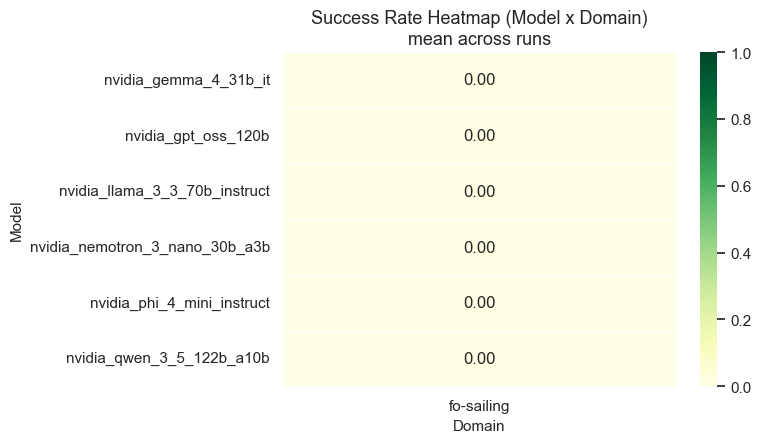

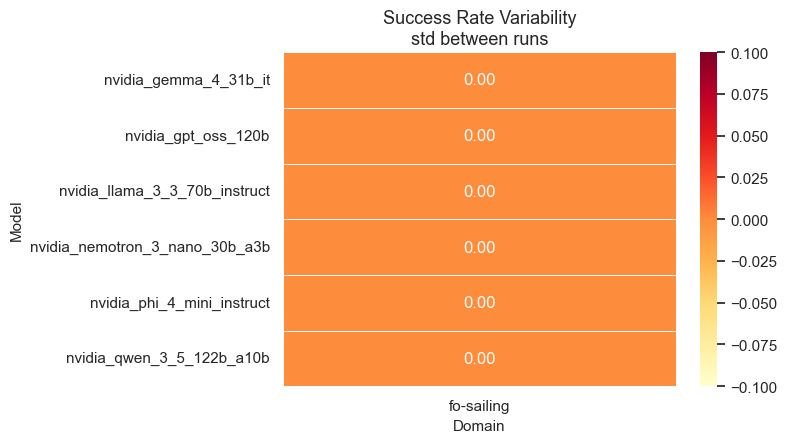

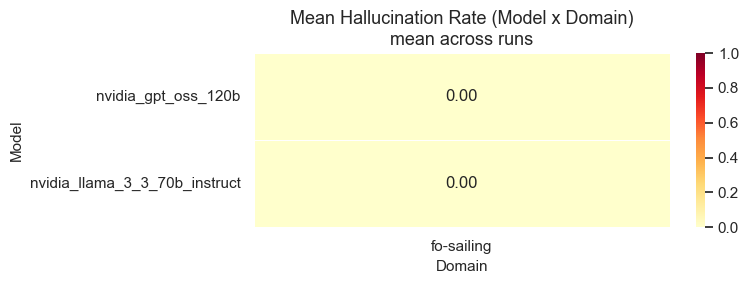

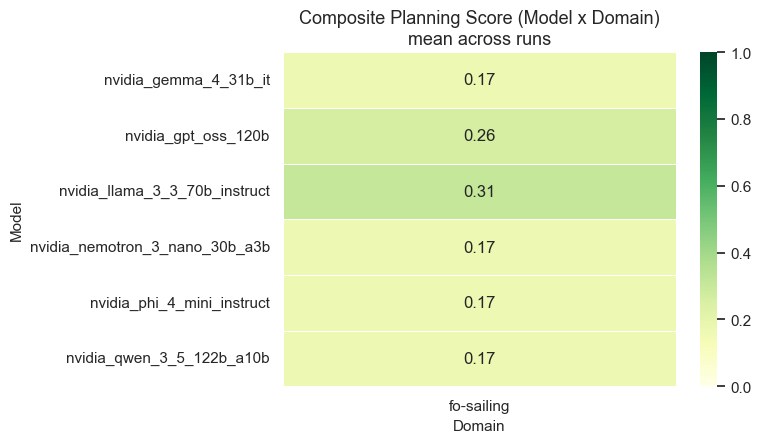

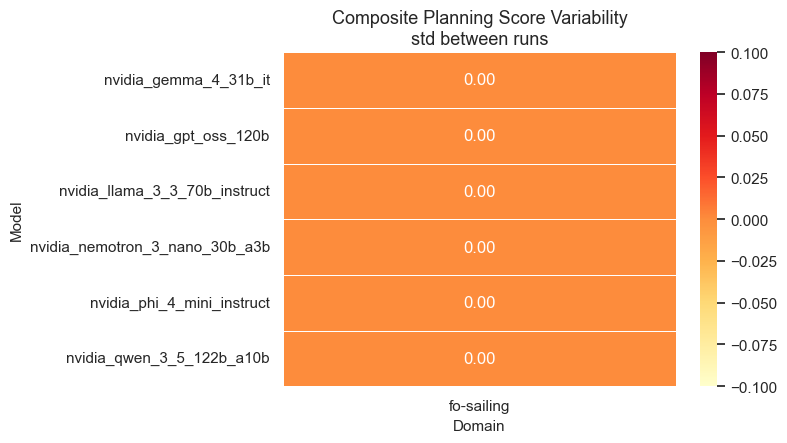

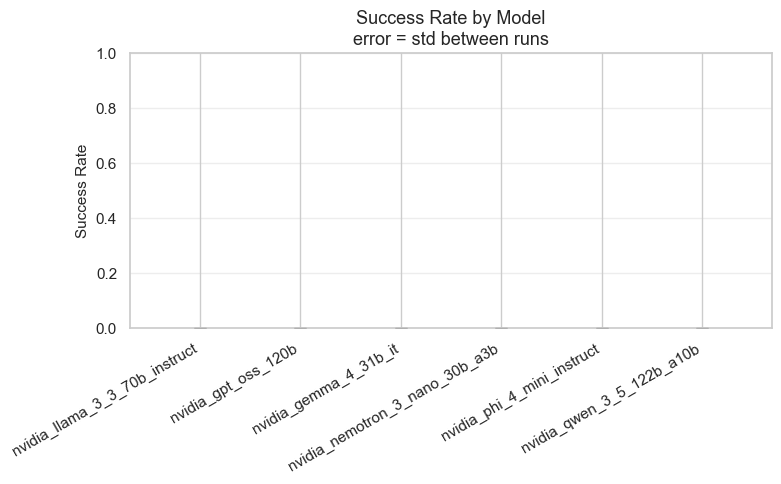

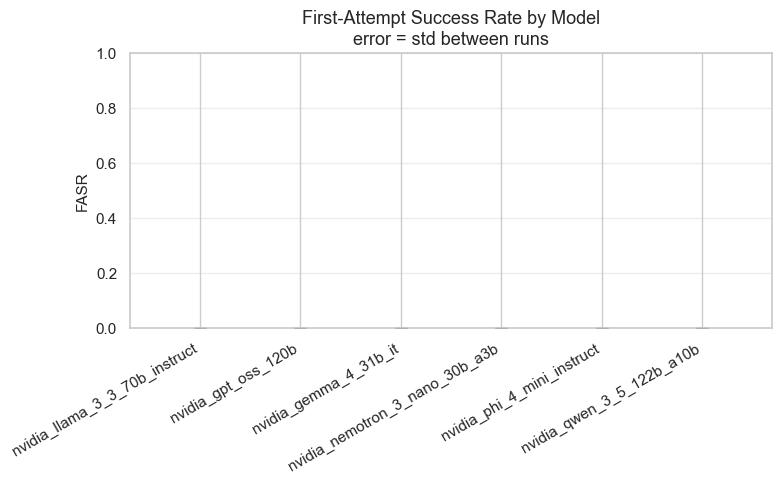

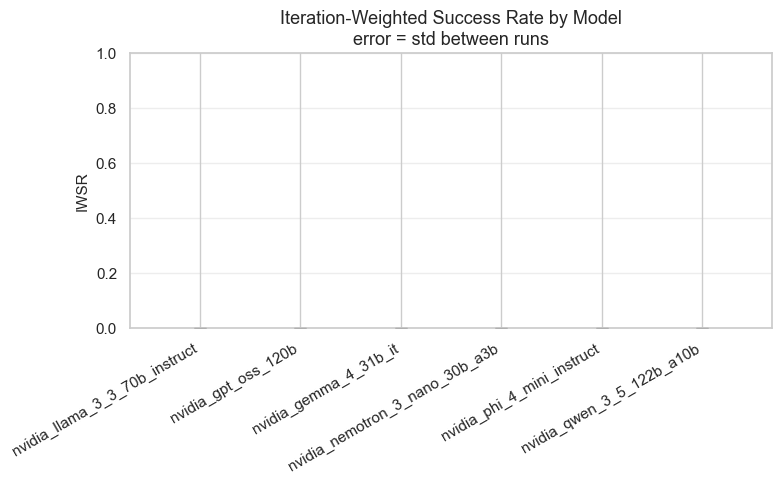

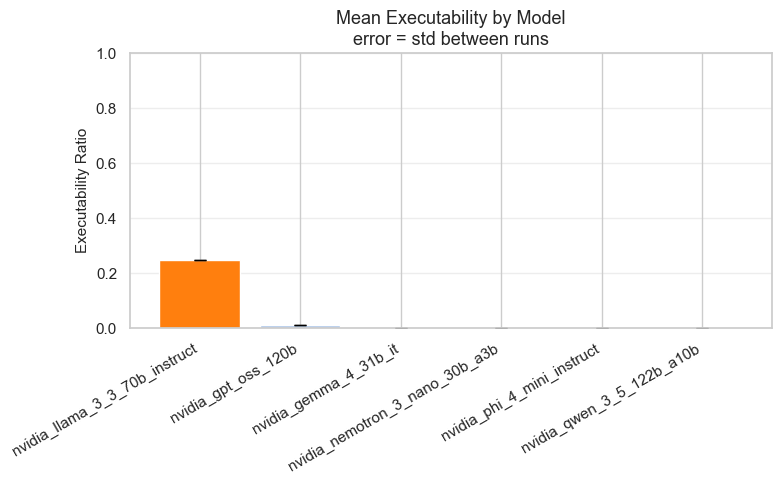

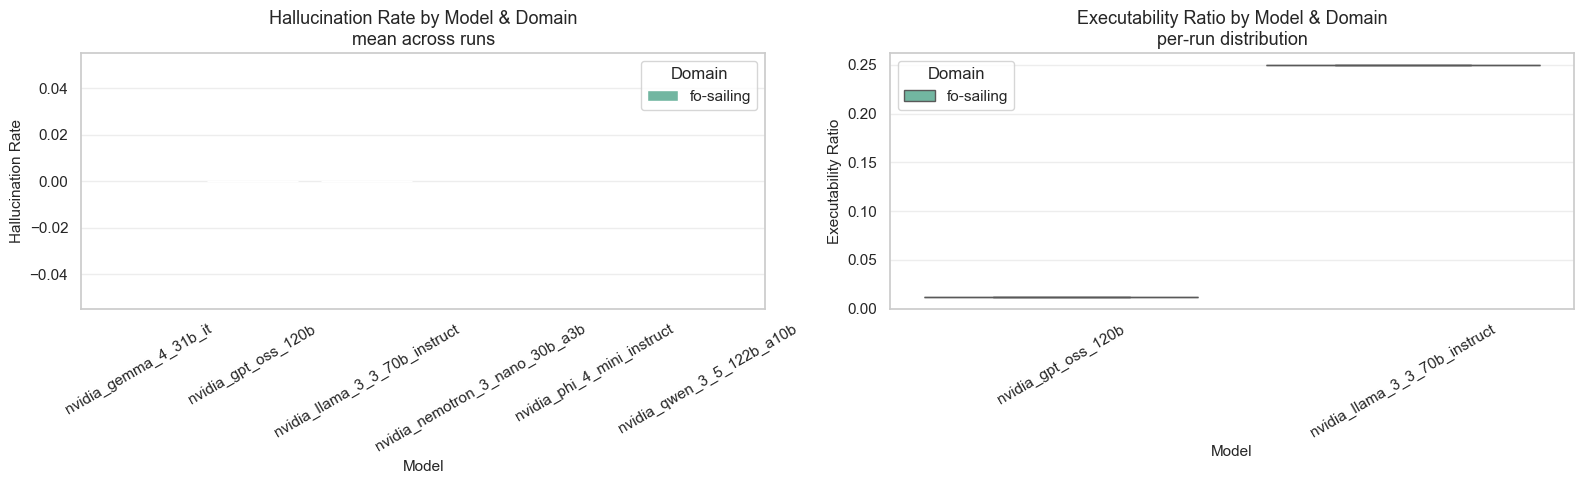

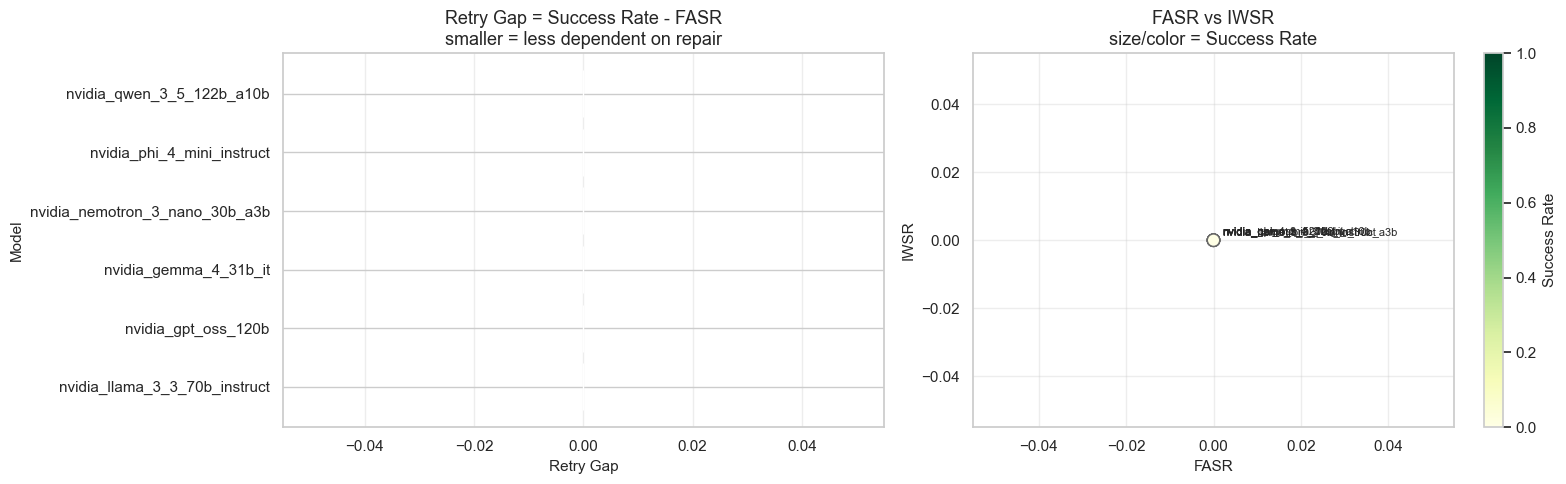

In [18]:
# -- Aggregated visualisations ------------------------------------------------
if agg_table.empty:
    print("No aggregated data available.")
else:
    _metric_heatmap(agg_table, "Success_Rate", "Success Rate Heatmap (Model x Domain)\nmean across runs", cmap="YlGn")
    _metric_heatmap(agg_table, "Success_Rate_std", "Success Rate Variability\nstd between runs", cmap="YlOrRd", vmin=0, vmax=None)
    _metric_heatmap(agg_table, "Halluc", "Mean Hallucination Rate (Model x Domain)\nmean across runs", cmap="YlOrRd")
    _metric_heatmap(agg_table, "PS", "Composite Planning Score (Model x Domain)\nmean across runs", cmap="YlGn")
    _metric_heatmap(agg_table, "PS_std", "Composite Planning Score Variability\nstd between runs", cmap="YlOrRd", vmin=0, vmax=None)

if not model_overall.empty:
    _model_bar_with_error(model_overall, "Success_Rate", "Success_Rate_std", "Success Rate by Model\nerror = std between runs", "Success Rate")
    _model_bar_with_error(model_overall, "FASR", "FASR_std", "First-Attempt Success Rate by Model\nerror = std between runs", "FASR")
    _model_bar_with_error(model_overall, "IWSR", "IWSR_std", "Iteration-Weighted Success Rate by Model\nerror = std between runs", "IWSR")
    _model_bar_with_error(model_overall, "Exec", "Exec_std", "Mean Executability by Model\nerror = std between runs", "Executability Ratio")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=agg_table, x="Model", y="Halluc", hue="Domain", ax=axes[0], palette="Set2")
    axes[0].set_title("Hallucination Rate by Model & Domain\nmean across runs")
    axes[0].set_xlabel("Model"); axes[0].set_ylabel("Hallucination Rate")
    axes[0].tick_params(axis="x", rotation=30); axes[0].grid(axis="y", alpha=.35)

    sns.boxplot(data=run_table.dropna(subset=["Exec"]), x="Model", y="Exec", hue="Domain", ax=axes[1], palette="Set2")
    axes[1].set_title("Executability Ratio by Model & Domain\nper-run distribution")
    axes[1].set_xlabel("Model"); axes[1].set_ylabel("Executability Ratio")
    axes[1].tick_params(axis="x", rotation=30); axes[1].grid(axis="y", alpha=.35)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    rg = model_overall.sort_values("Retry_Gap", ascending=True)
    axes[0].barh(rg["Model"], rg["Retry_Gap"], color=[MODEL_PALETTE.get(m, "steelblue") for m in rg["Model"]], edgecolor="white")
    axes[0].set_title("Retry Gap = Success Rate - FASR\nsmaller = less dependent on repair")
    axes[0].set_xlabel("Retry Gap"); axes[0].set_ylabel("Model"); axes[0].grid(axis="x", alpha=.35)

    sc = axes[1].scatter(model_overall["FASR"], model_overall["IWSR"],
                         s=model_overall["Success_Rate"] * 900 + 80,
                         c=model_overall["Success_Rate"], cmap="YlGn", vmin=0, vmax=1,
                         edgecolors="dimgray")
    for _, row in model_overall.iterrows():
        axes[1].annotate(row["Model"], (row["FASR"], row["IWSR"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
    plt.colorbar(sc, ax=axes[1], label="Success Rate")
    axes[1].set_title("FASR vs IWSR\nsize/color = Success Rate")
    axes[1].set_xlabel("FASR"); axes[1].set_ylabel("IWSR"); axes[1].grid(alpha=.35)
    plt.tight_layout(); plt.show()


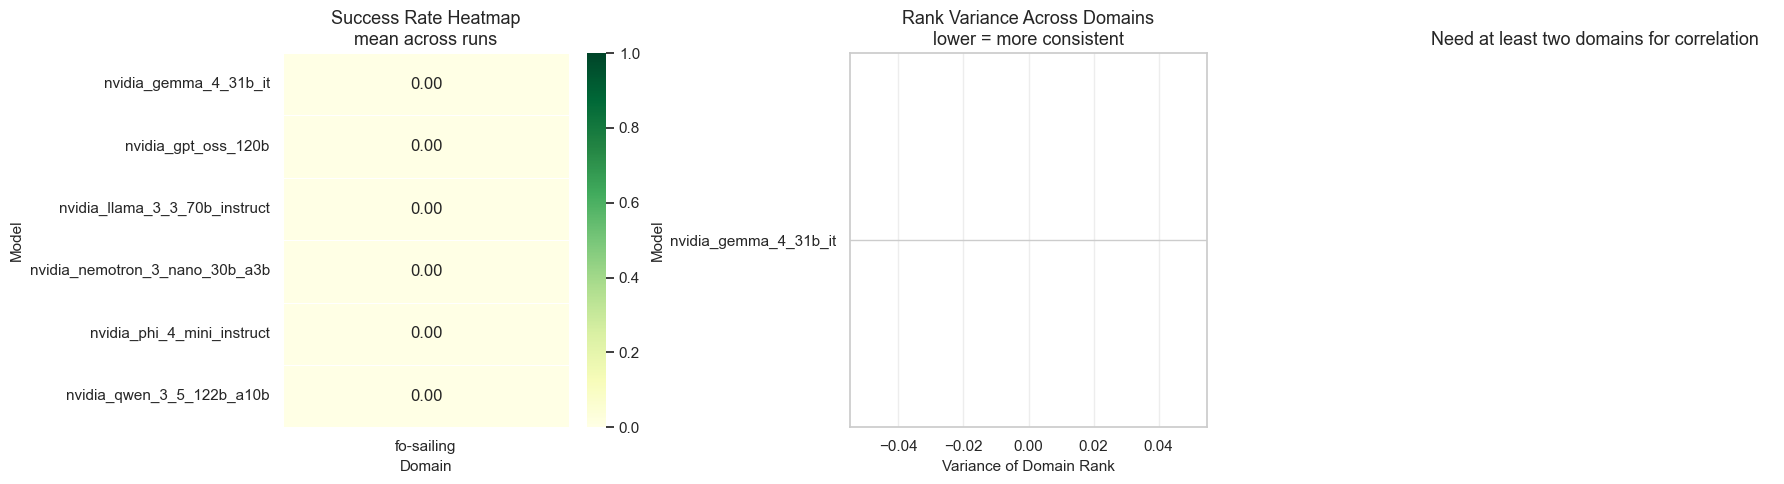

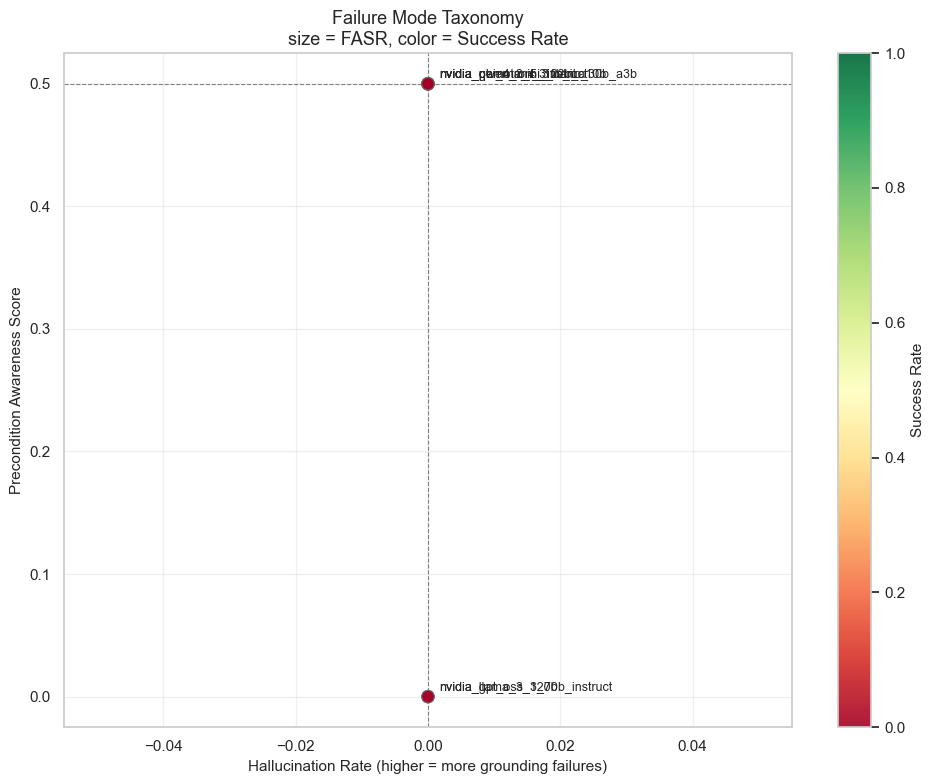

In [19]:
# -- Cross-domain consistency and failure taxonomy ----------------------------
if agg_table.empty:
    print("No cross-domain data available.")
else:
    sr_pivot = agg_table.pivot_table(values="Success_Rate", index="Model", columns="Domain", aggfunc="mean").fillna(0)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(sr_pivot, ax=axes[0], annot=True, fmt=".2f", cmap="YlGn", linewidths=.4, vmin=0, vmax=1)
    axes[0].set_title("Success Rate Heatmap\nmean across runs")
    axes[0].set_xlabel("Domain"); axes[0].set_ylabel("Model")

    sr_ranks = sr_pivot.rank(ascending=False, method="min")
    rank_var = sr_ranks.var(axis=1).reset_index()
    rank_var.columns = ["Model", "rank_variance"]
    rank_var = rank_var.sort_values("rank_variance")
    axes[1].barh(rank_var["Model"], rank_var["rank_variance"],
                 color=[MODEL_PALETTE.get(m, "steelblue") for m in rank_var["Model"]], edgecolor="white")
    axes[1].set_title("Rank Variance Across Domains\nlower = more consistent")
    axes[1].set_xlabel("Variance of Domain Rank"); axes[1].set_ylabel("Model"); axes[1].grid(axis="x", alpha=.35)

    if sr_pivot.shape[1] >= 2:
        corr_df = sr_pivot.corr(method="spearman")
        sns.heatmap(corr_df, ax=axes[2], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=.4)
        axes[2].set_title("Spearman Correlation of Model\nSuccess Rates Across Domains")
    else:
        axes[2].axis("off")
        axes[2].set_title("Need at least two domains for correlation")
    plt.tight_layout(); plt.show()

if not model_overall.empty:
    tax = model_overall.copy().fillna({"PAS": 0.5, "Halluc": 0.0, "FASR": 0.0, "Success_Rate": 0.0})
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(tax["Halluc"], tax["PAS"], s=tax["FASR"] * 1200 + 80,
                    c=tax["Success_Rate"], cmap="RdYlGn", vmin=0, vmax=1,
                    edgecolors="dimgray", linewidths=.8, alpha=.9, zorder=3)
    plt.colorbar(sc, ax=ax, label="Success Rate")
    for _, row in tax.iterrows():
        ax.annotate(row["Model"], (row["Halluc"], row["PAS"]), textcoords="offset points", xytext=(8, 4), fontsize=9)
    ax.axvline(tax["Halluc"].mean() if len(tax) else 0.5, color="gray", linestyle="--", linewidth=.8)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=.8)
    ax.set_xlabel("Hallucination Rate (higher = more grounding failures)")
    ax.set_ylabel("Precondition Awareness Score")
    ax.set_title("Failure Mode Taxonomy\nsize = FASR, color = Success Rate")
    ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()


---
# Section 5 - Composite Planning Score and Variability

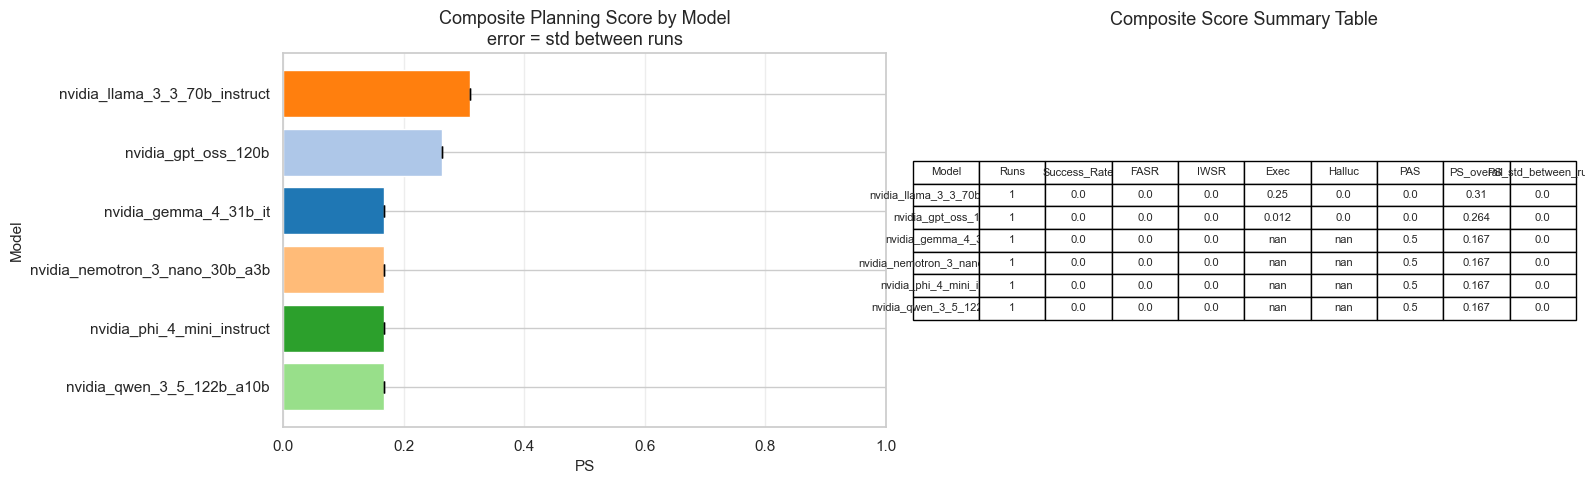

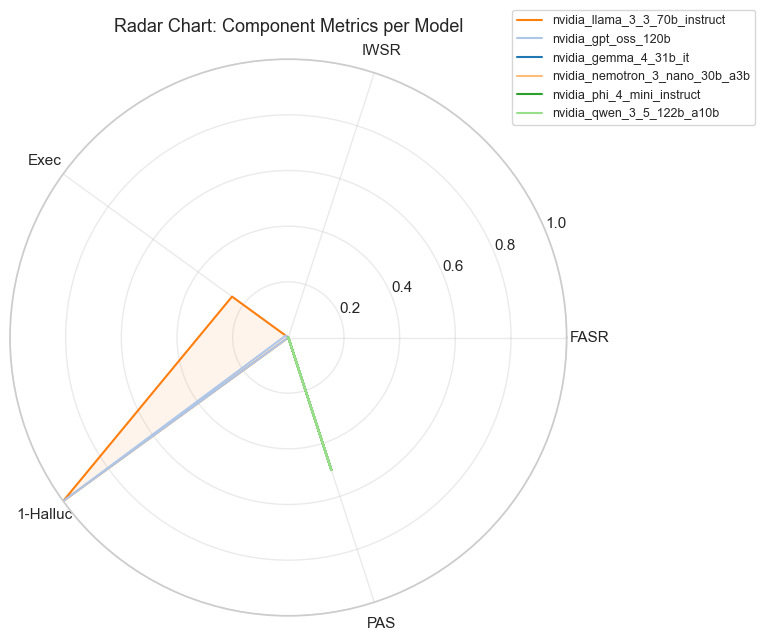

,Model,Runs,Success_Rate_std,FASR_std,IWSR_std,Exec_std,Halluc_std,PAS_std,PS_std,Instability_Index
2,nvidia_llama_3_3_70b_instruct,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,nvidia_gpt_oss_120b,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,nvidia_gemma_4_31b_it,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,nvidia_nemotron_3_nano_30b_a3b,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,nvidia_phi_4_mini_instruct,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,nvidia_qwen_3_5_122b_a10b,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# -- Composite Planning Score and run variability -----------------------------
if model_overall.empty:
    print("No PS data available.")
else:
    ps_overall = model_overall.rename(columns={"PS": "PS_overall", "PS_std": "PS_std_between_runs"}).sort_values("PS_overall", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    y = np.arange(len(ps_overall))
    axes[0].barh(y, ps_overall["PS_overall"], xerr=ps_overall["PS_std_between_runs"],
                 capsize=4, color=[MODEL_PALETTE.get(m, "steelblue") for m in ps_overall["Model"]], edgecolor="white")
    axes[0].set_yticks(y); axes[0].set_yticklabels(ps_overall["Model"])
    axes[0].invert_yaxis(); axes[0].set_xlim(0, 1)
    axes[0].set_title("Composite Planning Score by Model\nerror = std between runs")
    axes[0].set_xlabel("PS"); axes[0].set_ylabel("Model"); axes[0].grid(axis="x", alpha=.35)

    axes[1].axis("off")
    summary_table = ps_overall[["Model", "Runs", "Success_Rate", "FASR", "IWSR", "Exec", "Halluc", "PAS", "PS_overall", "PS_std_between_runs"]].round(3)
    table_plot = axes[1].table(cellText=summary_table.values, colLabels=summary_table.columns, cellLoc="center", loc="center")
    table_plot.auto_set_font_size(False)
    table_plot.set_fontsize(8)
    table_plot.scale(1.1, 1.4)
    axes[1].set_title("Composite Score Summary Table", pad=20)
    plt.tight_layout(); plt.show()

    radar_metrics = ["FASR", "IWSR", "Exec", "1-Halluc", "PAS"]
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]
    fig3, ax3 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for _, row in ps_overall.iterrows():
        values = [row["FASR"], row["IWSR"], row["Exec"], 1 - row["Halluc"], row["PAS"]]
        values = [0 if pd.isna(v) else float(v) for v in values] + [0 if pd.isna(values[0]) else float(values[0])]
        color = MODEL_PALETTE.get(row["Model"], "gray")
        ax3.plot(angles, values, linewidth=1.5, label=row["Model"], color=color)
        ax3.fill(angles, values, alpha=.08, color=color)
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(radar_metrics, fontsize=11)
    ax3.set_ylim(0, 1)
    ax3.set_title("Radar Chart: Component Metrics per Model", fontsize=13, pad=20)
    ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    ax3.grid(alpha=.4)
    plt.tight_layout(); plt.show()

    variability_table = model_overall[[
        "Model", "Runs", "Success_Rate_std", "FASR_std", "IWSR_std",
        "Exec_std", "Halluc_std", "PAS_std", "PS_std",
    ]].copy()
    variability_table["Instability_Index"] = variability_table[[
        "Success_Rate_std", "FASR_std", "IWSR_std", "Exec_std", "Halluc_std", "PAS_std", "PS_std"
    ]].mean(axis=1)
    variability_table = variability_table.sort_values("Instability_Index", ascending=False)
    display(variability_table.round(4))


---
# Summary Notes

This run-aware notebook keeps per-run values visible while using fair aggregation for the main plots. The default aggregate first computes metrics at the run level, then averages those values across runs so each run has equal weight.

Use `df_raw` for raw loaded artifacts, `df_metrics` for row-level metrics, `run_table` for per-run summaries, `agg_table` for Model x Domain aggregates, and `model_overall` for model-level summaries.
